# Activation-pattern contrasts

Each ligand carries a three-bit pattern over [class1, common, class2]. Grouping those
patterns gives the sets contrasted here:

- **class1 side** — `100` + `110`, bound by the class 1 ancestor but not class 2
- **class2 side** — `011`, bound by class 2 and the common ancestor but not class 1
- **shared** — `111`, bound by all three
- **common only** — `010`, held by the common ancestor and dropped by both

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
print(f"extant thresh  : {anc.threshold:.4f}   (reference only, not applied here)")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : absolute
ancestral cut  : median probability > 0.50
extant thresh  : 0.9150   (reference only, not applied here)
  common_ancestor    177 ligands
  class1_ancestor    130 ligands
  class2_ancestor    113 ligands

ligands active in at least one node: 266


In [2]:
chem = descriptors(anc.all_smiles).merge(functional_groups(anc.all_smiles), on="SMILES")
FG_COLS = list(FG_SMARTS)
chem.head()

,SMILES,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(C(=O)C(=O)O)O,-1.3676,74.60,104.061,2,3,1,1,0,1,0,0,0,0,0,0,0,0
1,C(C(=O)O)N,-0.9703,63.32,75.067,2,2,1,0,0,0,0,0,1,0,0,0,0,0
2,C(C(=O)O)S,0.0008,37.30,92.119,2,2,1,0,0,0,0,0,0,0,0,0,0,0
3,C(C(C(=O)O)N)N,-1.6430,89.34,104.109,3,3,1,0,0,0,0,0,1,0,0,0,0,0
4,C(C(C=O)O)O,-1.4615,57.53,90.078,2,3,0,1,1,0,0,0,0,0,0,0,0,0


## Group sizes

In [3]:
groups = {k: v for k, v in anc.code_sets.items()}
sizes = pd.Series({k: len(v) for k, v in groups.items()})
print(sizes.to_string())
save_table(sizes.rename("n_ligands").reset_index().rename(columns={"index": "group"}),
           "02_group_sizes")

class1_side    103
class2_side     86
shared          27
common_only     50


## The five presence patterns

Each ligand is a column; the three rows are the ancestral nodes. Columns are grouped by
pattern, and the strip above marks which group each column belongs to.

patterns kept for testing (n >= 5): {'100': 89, '111': 27, '011': 86, '010': 50, '110': 14}


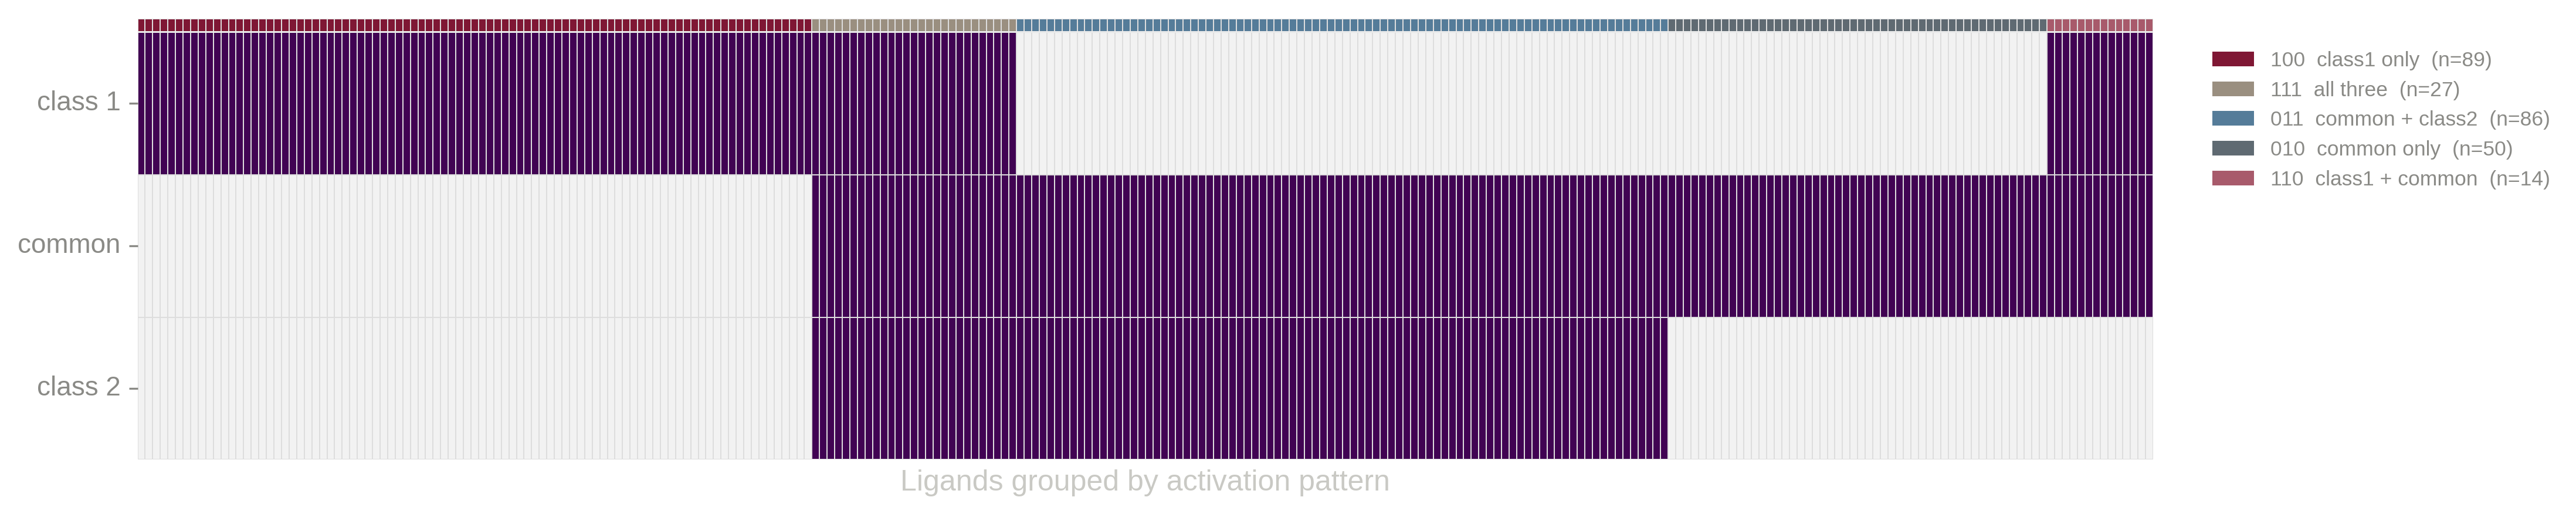

In [4]:
PAT_COL = {"100": CLASS1_COL, "110": "#a85a6b", "111": "#9a8f80",
           "010": COMMON_COL, "011": CLASS2_COL, "001": "#8fb0c4", "101": "#c9c9c4"}
KEEP = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p]) >= 5]
print("patterns kept for testing (n >= 5):", {p: len(anc.pattern_sets[p]) for p in KEEP})

X = anc.node_presence.set_index("SMILES")[
    ["class1_ancestor", "common_ancestor", "class2_ancestor"]].T
X.index = ["class 1", "common", "class 2"]
X = X.loc[:, X.sum(axis=0) > 0]

patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)
col_order = sorted(X.columns, key=lambda c: (PATTERN_ORDER.index(patterns.loc[c]), c))
Xo = X[col_order]
col_colors = patterns.loc[col_order].map(PAT_COL).tolist()
present = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p])]

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=ListedColormap(["#f2f2f2", "#410353"]),
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4, linecolor="#dddddd",
    figsize=(12, 3),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03),
)

ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis="y", left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")
ax.legend(handles=[Patch(facecolor=PAT_COL[p],
                         label=f"{p}  {PATTERN_LABELS[p]}  (n={len(anc.pattern_sets[p])})")
                   for p in present],
          bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False, fontsize=8.5)
save_fig(cg.figure, "02_pattern_heatmap")
save_table(anc.pattern_df, "02_ligand_patterns")
plt.show()

## class1 side versus class2 side

In [5]:
A = chem[chem.SMILES.isin(groups["class1_side"])]
B = chem[chem.SMILES.isin(groups["class2_side"])]

def cliffs(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return float(np.sign(x[:, None] - y[None, :]).mean())

rows = []
for d in DESCRIPTORS:
    a, b = A[d].dropna(), B[d].dropna()
    p = mannwhitneyu(a, b).pvalue
    rows.append({"descriptor": d, "class1_side": round(a.median(), 2),
                 "class2_side": round(b.median(), 2),
                 "cliffs_delta": round(cliffs(a, b), 2), "p": p})
res = pd.DataFrame(rows)
print(res.to_string(index=False))
save_table(res, "02_side_descriptors")

descriptor  class1_side  class2_side  cliffs_delta            p
      logP         1.88         2.40         -0.30 4.548026e-04
      TPSA        37.30        17.07          0.71 1.903811e-17
        MW       158.24       150.22          0.02 7.791855e-01
       HBD         1.00         0.00          0.62 9.911681e-16
       HBA         1.00         1.00          0.14 6.433596e-02


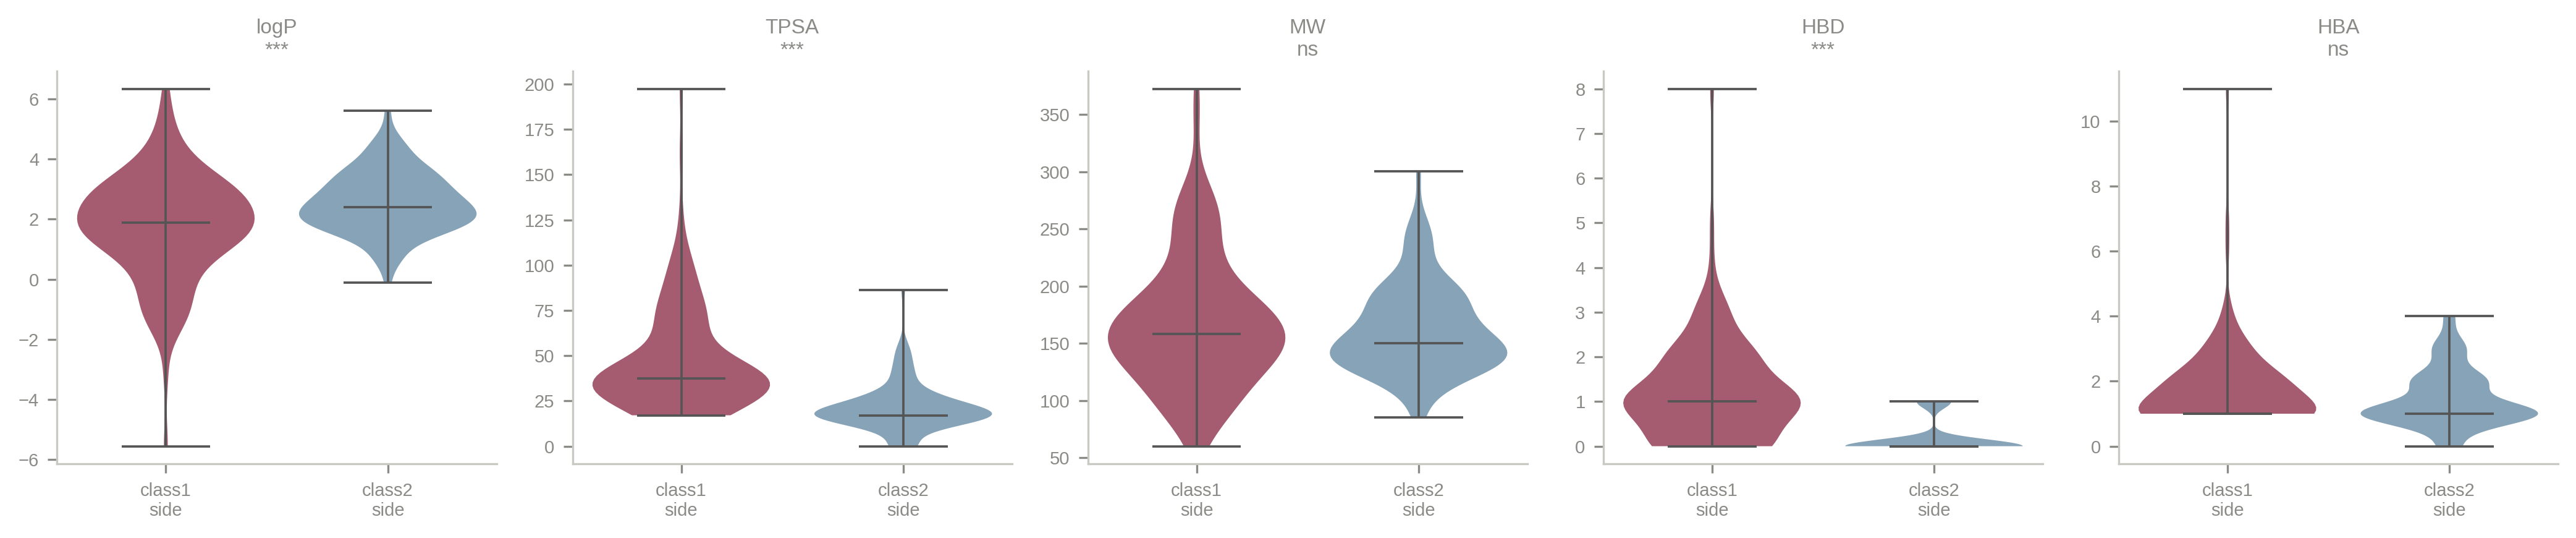

In [6]:
fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.7, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [A[d].dropna().values, B[d].dropna().values]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, c in zip(parts["bodies"], [CLASS1_COL, CLASS2_COL]):
        pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    p = float(res.loc[res.descriptor == d, "p"].iloc[0])
    s = "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"
    ax.set_title(f"{d}\n{s}", fontsize=8)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["class1\nside", "class2\nside"], fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_side_descriptors"); plt.show()

## Functional groups in the two sides

          group  class1_side_%  class2_side_%            p
carboxylic_acid           68.0            1.2 6.564440e-25
          ether           23.3           23.3 1.000000e+00
          ester           17.5           11.6 3.071399e-01
  aromatic_ring           14.6           52.3 2.688420e-08
         alkene           12.6           45.3 5.964915e-07
       aldehyde           11.7           16.3 4.006232e-01
        alcohol            7.8            5.8 7.746803e-01
          amide            4.9            1.2 2.227587e-01
         phenol            4.9            3.5 7.298249e-01
          amine            4.9            4.7 1.000000e+00
         ketone            2.9           30.2 2.065447e-07
        nitrile            0.0            1.2 4.550265e-01


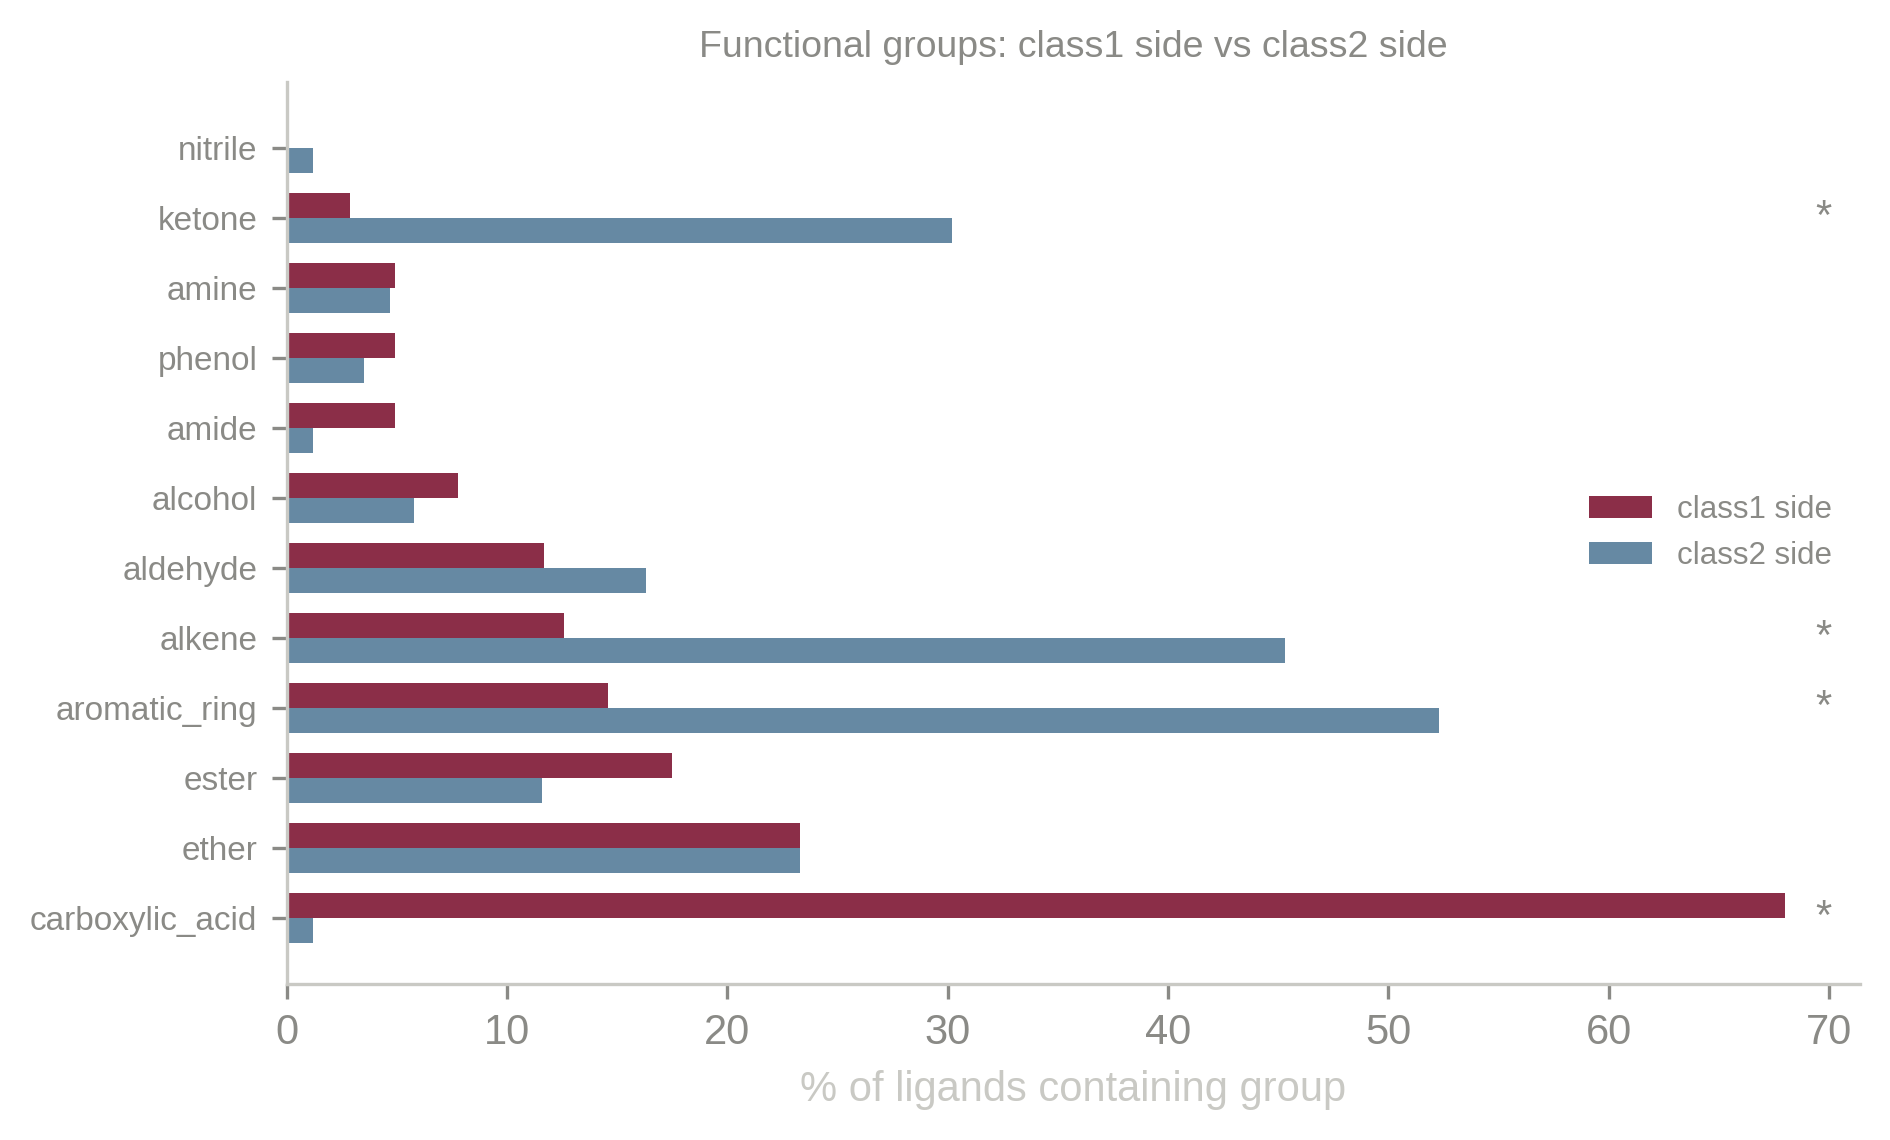

In [7]:
rows = []
for fg in FG_COLS:
    a, b = A[fg], B[fg]
    p = fisher_exact([[int(a.sum()), len(a) - int(a.sum())],
                      [int(b.sum()), len(b) - int(b.sum())]])[1]
    rows.append({"group": fg, "class1_side_%": round(100 * a.mean(), 1),
                 "class2_side_%": round(100 * b.mean(), 1), "p": p})
fg_res = pd.DataFrame(rows).sort_values("class1_side_%", ascending=False)
print(fg_res.to_string(index=False))
save_table(fg_res, "02_side_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.3))
y = np.arange(len(fg_res)); w = 0.36
ax.barh(y + w / 2, fg_res["class1_side_%"], w, color=CLASS1_COL, alpha=0.9, label="class1 side")
ax.barh(y - w / 2, fg_res["class2_side_%"], w, color=CLASS2_COL, alpha=0.9, label="class2 side")
xm = max(fg_res["class1_side_%"].max(), fg_res["class2_side_%"].max())
for yi, p in zip(y, fg_res["p"]):
    if p < 0.05: ax.text(xm * 1.02, yi, "*", va="center", fontsize=10, color="#8a8a86")
ax.set_yticks(y); ax.set_yticklabels(fg_res["group"], fontsize=8)
ax.set_xlabel("% of ligands containing group"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Functional groups: class1 side vs class2 side", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_side_functional_groups"); plt.show()

## Chemistry across the patterns

Kruskal-Wallis across the patterns for the descriptors, then the functional groups that
differ most.

descriptor     H            p    100    111    011    010    110
      logP  22.8 1.388792e-04   1.82   3.24   2.40   2.51   2.47
      TPSA 100.0 9.904557e-21  37.30  34.14  17.07  26.30  26.30
        MW  41.2 2.498877e-08 158.24 264.41 150.22 162.21 160.19
       HBD 102.1 3.535397e-21   1.00   1.00   0.00   0.00   0.00
       HBA  18.1 1.202211e-03   1.00   2.00   1.00   2.00   2.00


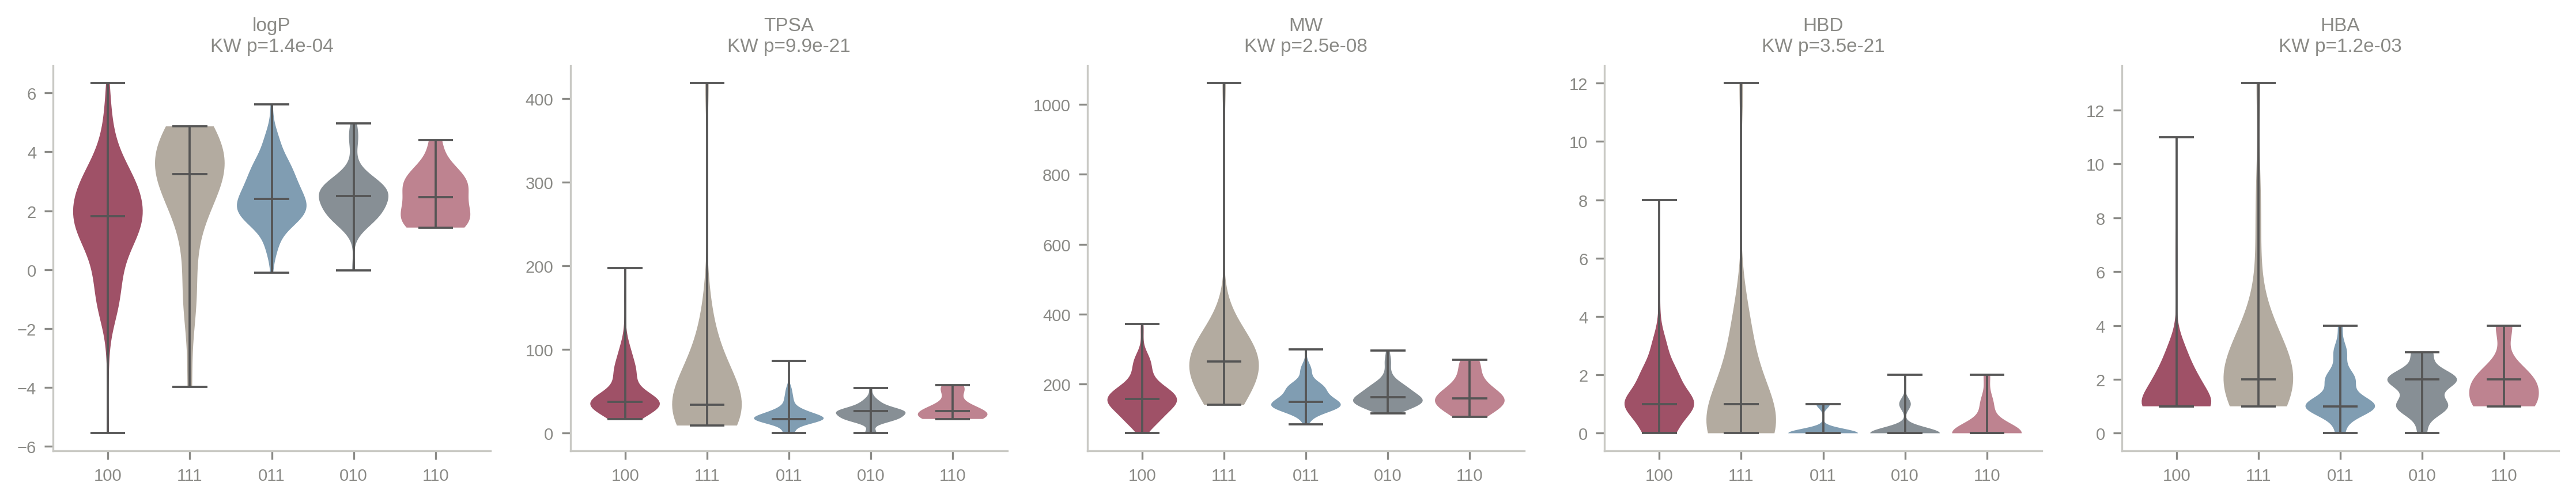

In [8]:
pat_chem = pd.concat([chem[chem.SMILES.isin(anc.pattern_sets[p])].assign(pattern=p)
                      for p in KEEP])

rows = []
for d in DESCRIPTORS:
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    h, pv = kruskal(*data)
    rows.append({"descriptor": d, "H": round(h, 1), "p": pv,
                 **{p: round(np.median(x), 2) for p, x in zip(KEEP, data)}})
print(pd.DataFrame(rows).to_string(index=False))
save_table(pd.DataFrame(rows), "02_pattern_descriptors")

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.75, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    parts = ax.violinplot(data, showmedians=True, widths=0.85)
    for pc, p in zip(parts["bodies"], KEEP):
        pc.set_facecolor(PAT_COL[p]); pc.set_alpha(0.75); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    pv = float([r["p"] for r in rows if r["descriptor"] == d][0])
    ax.set_title(f"{d}\nKW p={pv:.1e}", fontsize=8)
    ax.set_xticks(range(1, len(KEEP) + 1)); ax.set_xticklabels(KEEP, fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_pattern_descriptors"); plt.show()

                  100   111   011   010   110  spread
carboxylic_acid  76.4   3.7   1.2   0.0  14.3    76.4
alkene            7.9  51.9  45.3  30.0  42.9    44.0
aromatic_ring    11.2  40.7  52.3  50.0  35.7    41.1
ketone            3.4  40.7  30.2   8.0   0.0    40.7
ester            12.4  22.2  11.6  36.0  50.0    38.4
ether            19.1  40.7  23.3  54.0  50.0    34.9
alcohol           7.9  37.0   5.8   6.0   7.1    31.2
aldehyde          9.0   0.0  16.3  18.0  28.6    28.6
amine             5.6  14.8   4.7   2.0   0.0    14.8
phenol            4.5  11.1   3.5   2.0   7.1     9.1
amide             5.6   7.4   1.2   4.0   0.0     7.4
nitrile           0.0   0.0   1.2   0.0   0.0     1.2


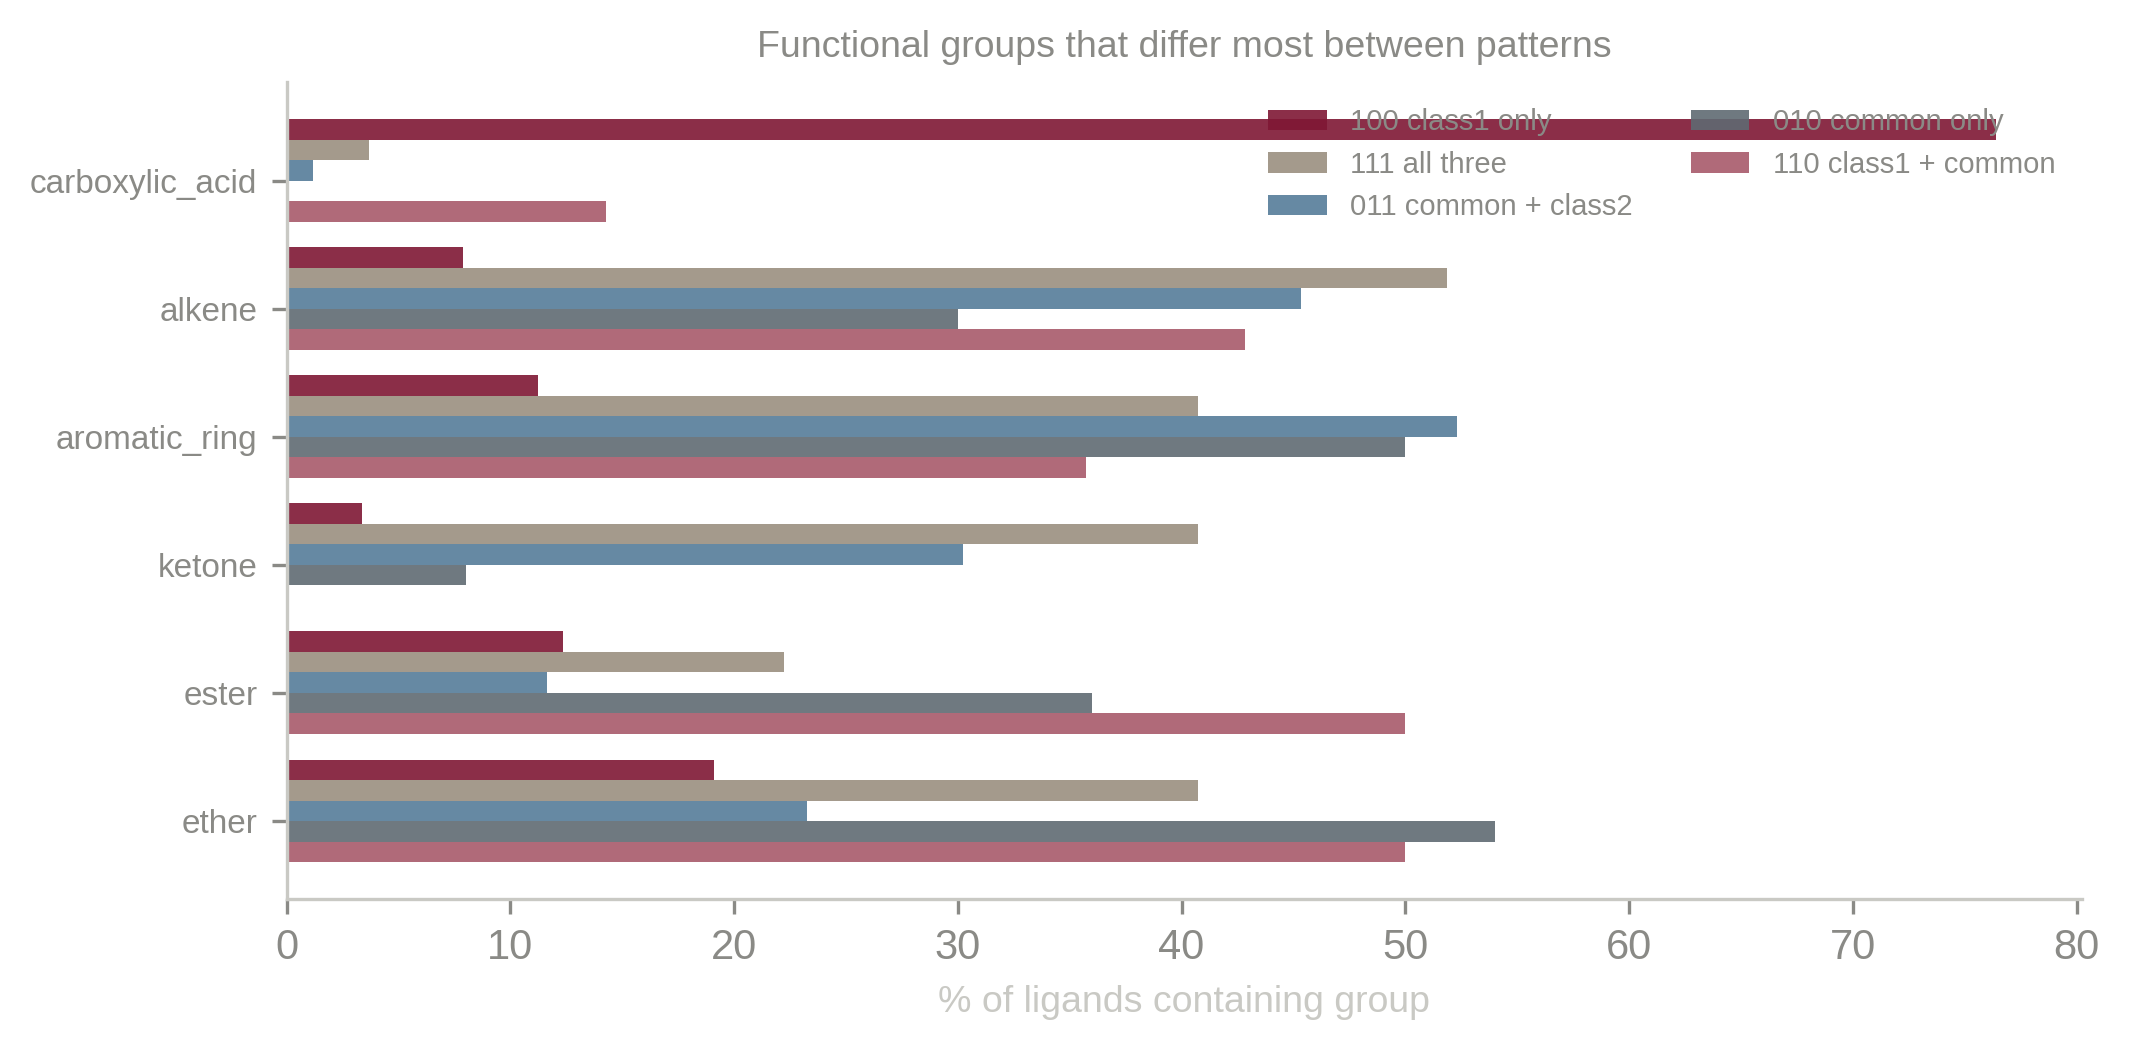

In [9]:
fg_pat = pd.DataFrame({p: chem[chem.SMILES.isin(anc.pattern_sets[p])][FG_COLS].mean() * 100
                       for p in KEEP})
fg_pat["spread"] = fg_pat.max(axis=1) - fg_pat.min(axis=1)
fg_pat = fg_pat.sort_values("spread", ascending=False)
print(fg_pat.round(1).to_string())
save_table(fg_pat.reset_index().rename(columns={"index": "functional_group"}),
           "02_pattern_functional_groups")

show = fg_pat.drop(columns="spread").head(6)
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
y = np.arange(len(show)); w = 0.8 / len(KEEP)
for i, p in enumerate(KEEP):
    ax.barh(y + (i - len(KEEP) / 2) * w, show[p], w, color=PAT_COL[p], alpha=0.9,
            label=f"{p} {PATTERN_LABELS[p]}")
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("% of ligands containing group", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncol=2)
ax.set_title("Functional groups that differ most between patterns", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_pattern_functional_groups"); plt.show()

## Odour-descriptor enrichment

Hypergeometric test of each pattern against the pooled ligand universe, uncorrected.
Bars show fold enrichment, grouped by pattern.

With five patterns and ~30 descriptors this is ~150 tests, so roughly seven hits are
expected at p < 0.05 by chance alone. Read the fold enrichment and the observed counts,
not the p-values on their own.

In [10]:
from scipy.stats import hypergeom

tag_map = dict(zip(odor_tags().SMILES, odor_tags().tags))
universe = anc.all_smiles
tagged = [s for s in universe if tag_map.get(s)]
N = len(tagged)
tag_total = pd.Series([t for s in tagged for t in tag_map[s]]).value_counts()
tag_total = tag_total[tag_total >= 5]

rows = []
for p in KEEP:
    members = [s for s in anc.pattern_sets[p] if s in tag_map and tag_map[s]]
    n = len(members)
    counts = pd.Series([t for s in members for t in tag_map[s]]).value_counts()
    for tag, K in tag_total.items():
        k = int(counts.get(tag, 0))
        exp = n * K / N
        rows.append({"pattern": p, "tag": tag, "obs": k, "exp": round(exp, 2),
                     "obs_exp": k / exp if exp else 0,
                     "p": hypergeom.sf(k - 1, N, K, n) if k else 1.0})
enr = pd.DataFrame(rows)
sig = enr[(enr.p < 0.05) & (enr.obs_exp > 1)]
print(f"{len(enr)} tests ({len(KEEP)} patterns x {len(tag_total)} tags), uncorrected")
print(f"{len(sig)} pattern-tag pairs at p < 0.05; ~{0.05 * len(enr):.0f} expected by chance\n")
print(sig.sort_values(["pattern", "obs_exp"], ascending=[True, False]).to_string(index=False))
save_table(enr, "02_odour_enrichment")

345 tests (5 patterns x 69 tags), uncorrected
30 pattern-tag pairs at p < 0.05; ~17 expected by chance

pattern        tag  obs   exp  obs_exp            p
    011  medicinal    5  2.22 2.251244 2.673507e-02
    011   terpenic    5  2.22 2.251244 2.673507e-02
    011    roasted    5  2.22 2.251244 2.673507e-02
    011     coffee    5  2.22 2.251244 2.673507e-02
    011       plum    6  2.96 2.026119 3.064671e-02
    011      berry    6  2.96 2.026119 3.064671e-02
    011      meaty    6  2.96 2.026119 3.064671e-02
    011      minty    6  2.96 2.026119 3.064671e-02
    011  sulfurous    7  3.70 1.891045 3.173645e-02
    011      spicy   12  7.03 1.706206 1.363258e-02
    011     herbal   14  8.51 1.644387 1.161335e-02
    011      woody   16 10.73 1.490479 2.405778e-02
    100   odorless   10  2.93 3.415094 2.414936e-06
    100     acidic    5  1.46 3.415094 1.874209e-03
    100       sour   14  4.10 3.415094 8.666151e-09
    100     cheesy   14  4.98 2.812431 2.808397e-06
    100     

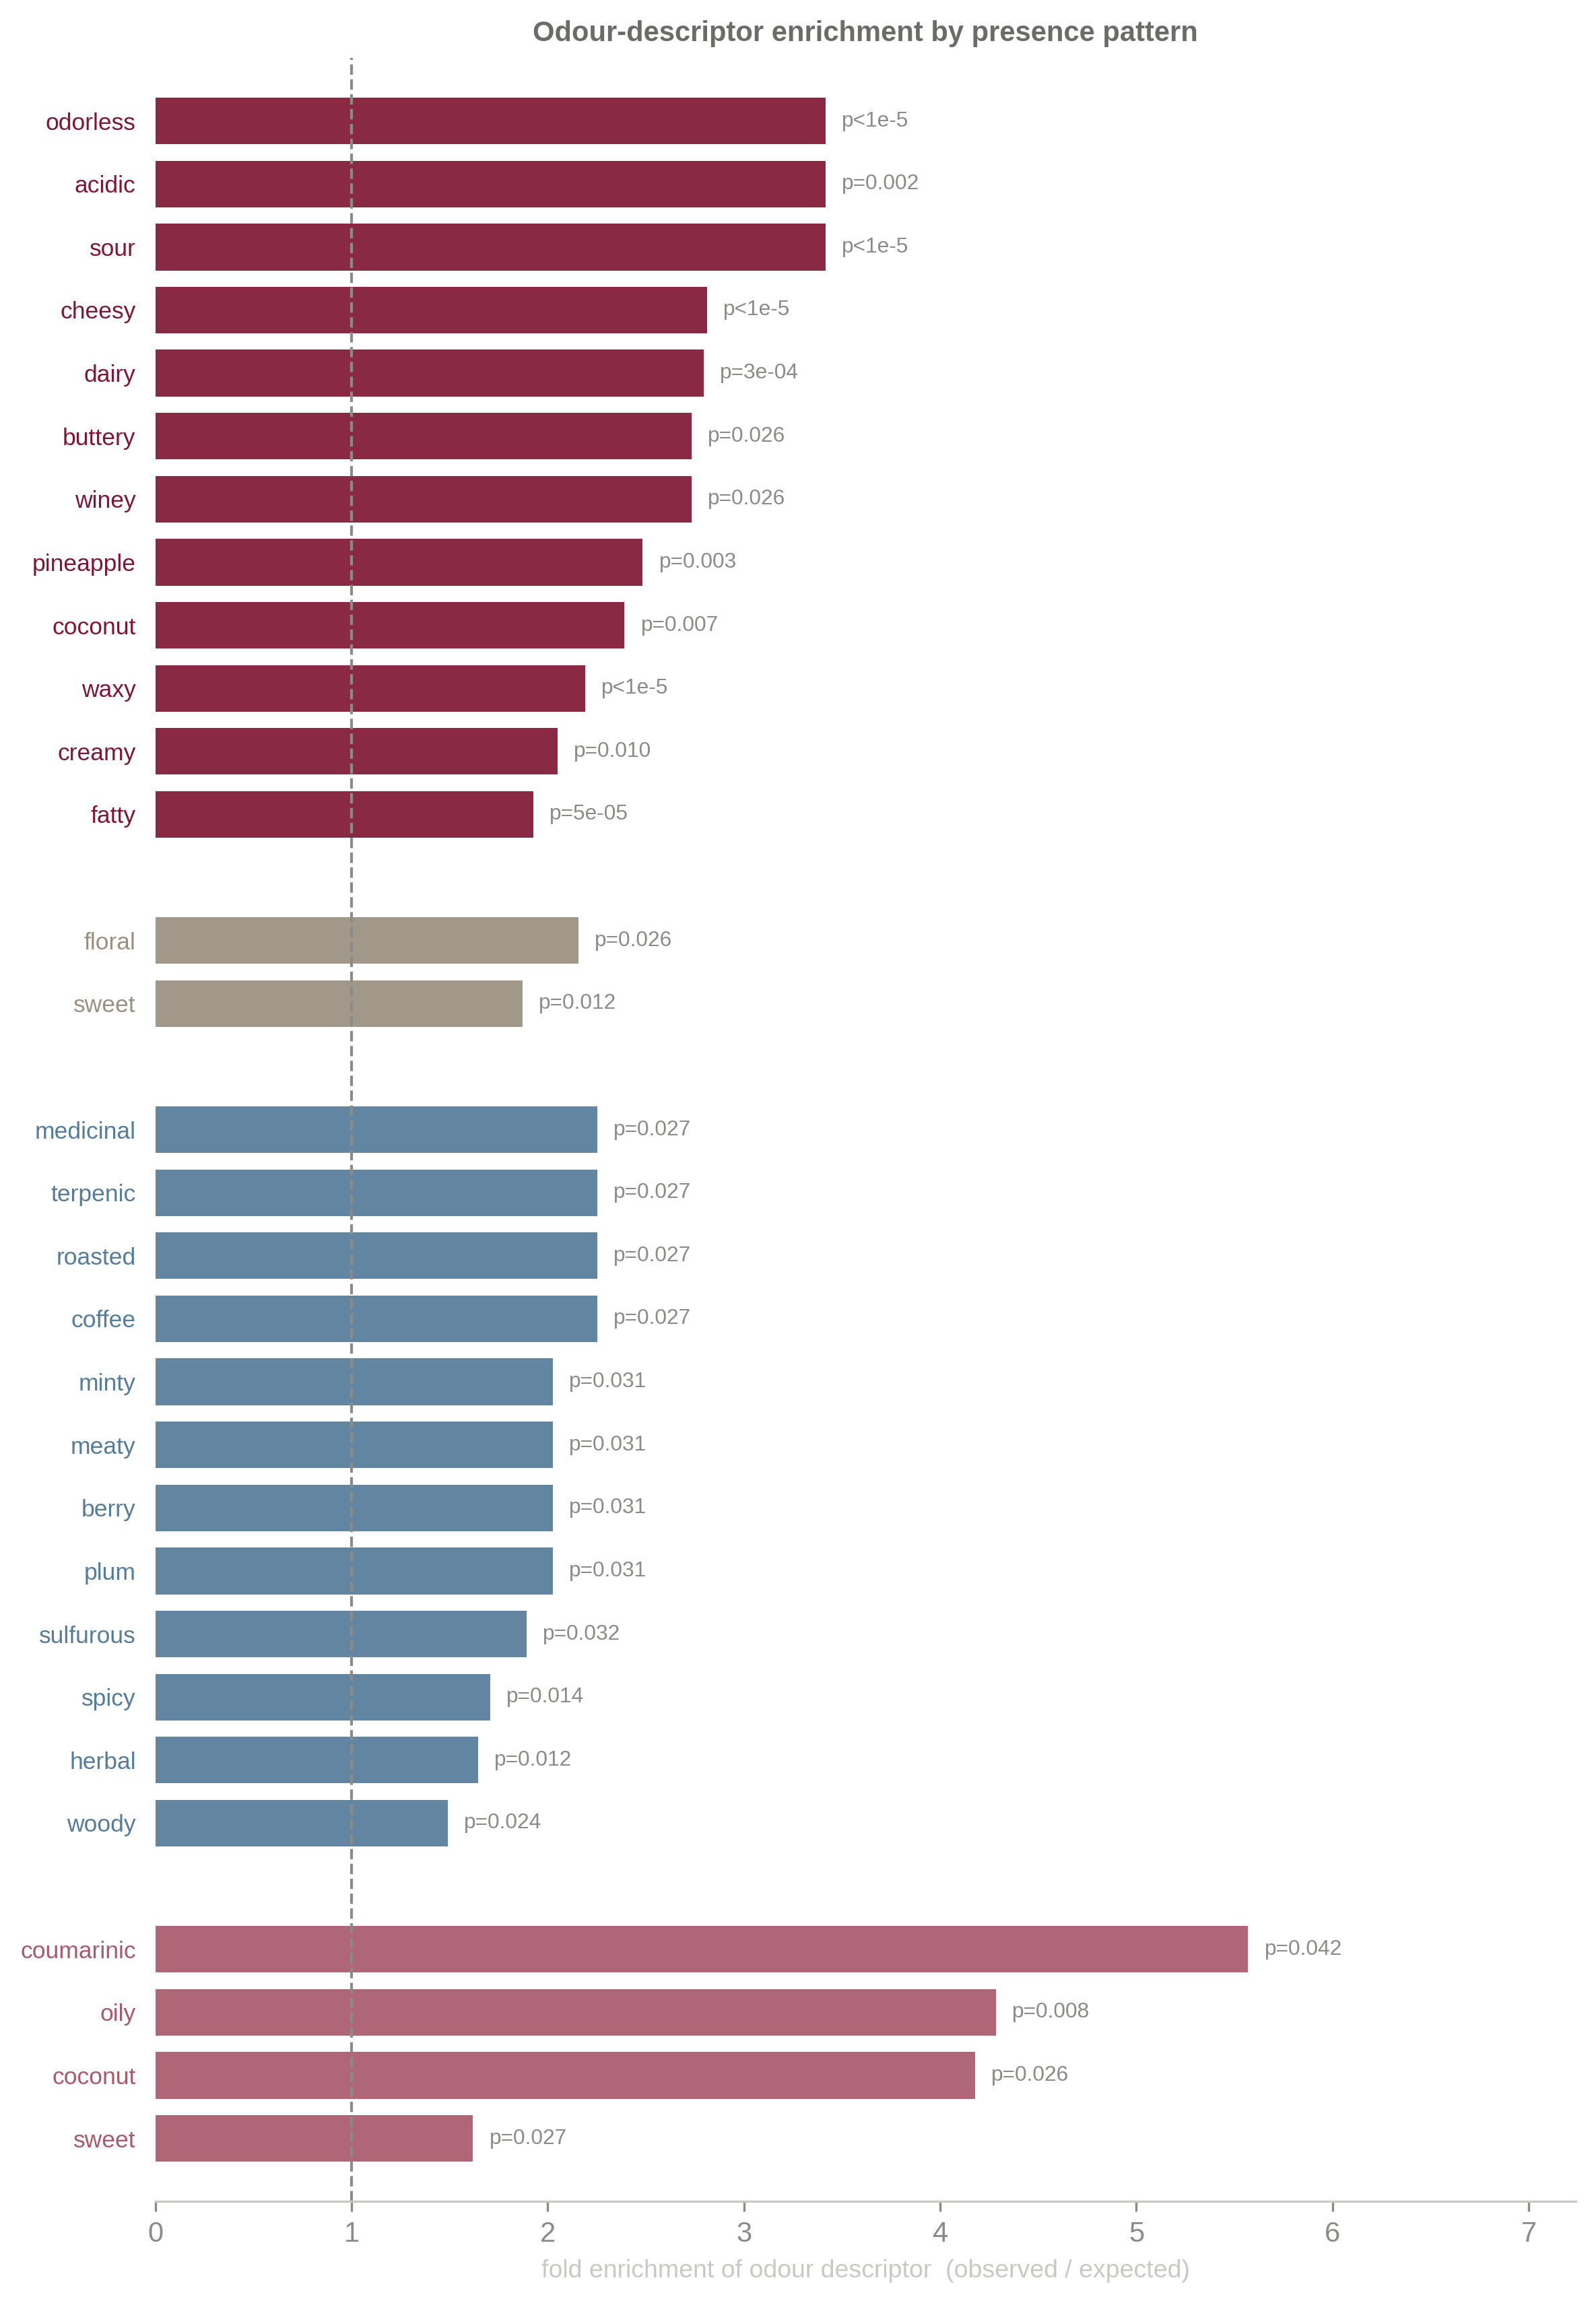

In [11]:
def fmt_p(v):
    if v < 1e-5: return "p<1e-5"
    if v < 1e-3: return "p=%.0e" % v
    return "p=%.3f" % v

rows = []
for p in KEEP:
    for r in sig[sig.pattern == p].sort_values("obs_exp", ascending=False).itertuples():
        rows.append((p, r.tag, r.obs_exp, r.p))

ys, labels, colors, folds, qs = [], [], [], [], []
y, last = 0, None
for p, tag, fold, qv in rows:
    if last is not None and p != last: y -= 1
    ys.append(y); labels.append(tag); colors.append(PAT_COL[p])
    folds.append(fold); qs.append(qv); y -= 1; last = p
ys, folds = np.array(ys), np.array(folds)

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 2, 0.3 * (len(labels) + len(KEEP)) + 1))
ax.barh(ys, folds, color=colors, alpha=0.92, height=0.74)
ax.axvline(1, color="#8a8a86", ls="--", lw=1.0)
xm = folds.max()
for yi, f, qv in zip(ys, folds, qs):
    ax.text(f + xm * 0.015, yi, fmt_p(qv), va="center", ha="left", fontsize=7.6, color="#8a8a86")
ax.set_yticks(ys); ax.set_yticklabels(labels, fontsize=8.5)
for tl, c in zip(ax.get_yticklabels(), colors): tl.set_color(c)
ax.set_xlim(0, xm * 1.30); ax.set_ylim(ys.min() - 1, ys.max() + 1)
ax.set_xlabel("fold enrichment of odour descriptor  (observed / expected)", fontsize=9)
ax.set_title("Odour-descriptor enrichment by presence pattern", fontsize=10, fontweight="bold", color="#6b6b67")
for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout(); save_fig(fig, "02_odour_enrichment"); plt.show()